# 06 — LSTM Model (Weekly)

Uses **weekly-aggregated** data (W-FRI resampling, same as ARIMA/VAR/RF/XGBoost) to
predict the next week's silver log-return. Directly comparable to the other weekly models.

**Rebalancing assumption**: the model observes features up to Friday close at week $t-1$,
predicts the direction of the return from Friday close $t-1$ to Friday close $t$, and
a position is taken at Friday close $t-1$. All features are lagged accordingly — no
intra-week information is used. The LSTM's `SEQ_LEN` window provides the temporal
lag implicitly: the sequence ending Friday $t-1$ contains values from $t-\text{SEQ\_LEN}$
through $t-1$, predicting $y_t$ (the return from Fri $t-1$ to Fri $t$).

**Why not t+5 (daily input, 5-day-ahead)?**
That formulation predicts the cumulative 5-day return starting from each *daily* observation.
Adjacent predictions therefore share 4 of their 5 target days: the model trained on day $t$
and the model trained on day $t+1$ are evaluated against largely the same realised returns.
This target overlap inflates DA and WDA — a model that calls the direction of days 2–5
correctly at step $t$ will appear to also call days 1–4 correctly at step $t+1$ by
construction, not by genuine forecasting skill. Restricting evaluation to Fridays only
eliminates the overlap but collapses back to the same ~175 non-overlapping weekly
observations, so the t+5 formulation offers no advantage over this notebook.

**Limitation**: only ~330 training sequences after aggregation and SEQ_LEN warmup.
Walk-forward retraining was tested but degraded performance — with so few sequences each
fine-tune step adds negligible new signal while pushing the model out of its optimal
configuration. A single train on the full training set with early stopping on validation
loss is used instead. The `06b_lstm_walkforward.ipynb` companion notebook tests a
periodic-fine-tune variant for comparison.

**Methodology alignment with RF / XGBoost**: same `EXOG` definition (silver +
6 cross-asset returns + gold/silver ratio z-score), same 4 tech indicators,
parallel variant ladder including a NonLin variant, same naïve $y_{t-1}$ baseline,
and a one-shot **hyperparameter grid** (`SEQ_LEN`, `HIDDEN`, `DROPOUT`) tuned on
val loss using the EXOG variant and reused across all variants.
We do **not** test rolling vs expanding windows here: with only ~80 sequences
inside a 100-week rolling window after `SEQ_LEN` warmup, a rolling-window LSTM is
borderline trainable. The walk-forward fine-tune in `06b` is the LSTM-native analogue
of refitting on recent data.

`EXOG` = weekly silver return + 6 cross-asset returns (gold, USD, copper, S&P500, VIX, oil)
+ gold/silver ratio z-score (level, train-period normalised).

**NonLin features** = squared values of silver return and each cross-asset return — capture
volatility / magnitude information motivated by ARCH-style volatility clustering. No explicit
lag needed (the SEQ_LEN window handles it).

| Variant | Features |
|---|---|
| LSTM-Y | Silver return only |
| LSTM-TECH | Silver + macd\_line, macd\_hist, bb\_bandwidth, silver\_vol\_5w (no cross-assets) |
| LSTM-EXOG | Silver + 6 cross-asset returns + gs\_ratio\_z |
| LSTM-EXOG-NONLIN | EXOG + squared silver return + squared cross-asset returns |
| LSTM-EXOG-TECH | EXOG + tech indicators |
| LSTM-EXOG-REDDIT | EXOG + Reddit sentiment |
| LSTM-EXOG-NEWS | EXOG + news sentiment |
| LSTM-EXOG-SENTIMENT | EXOG + Reddit + news sentiment |
| LSTM-EXOG-TECH-SENTIMENT | EXOG + tech + Reddit + news sentiment |

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings, os, sys
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 120

DEVICE = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: mps


## 1. Hyperparameters

In [158]:
SEQ_LEN  = 20    # lookback: 20 weeks (~5 months)
HORIZON  = 1     # 1 week ahead
HIDDEN   = 32
N_LAYERS = 1
DROPOUT  = 0.2
EPOCHS   = 150
LR       = 1e-3
PATIENCE = 15
BATCH    = 16    # smaller batch — fewer sequences

TARGET = 'silver_return'

## 2. Load & aggregate to weekly

In [159]:
train_d = pd.read_csv('../../data/processed/train.csv', index_col=0, parse_dates=True)
val_d   = pd.read_csv('../../data/processed/val.csv',   index_col=0, parse_dates=True)
test_d  = pd.read_csv('../../data/processed/test.csv',  index_col=0, parse_dates=True)

EXOG_RETURNS = ['gold_return', 'usd_return', 'copper_return',
                'sp500_return', 'vix_return', 'oil_return']
EXOG_LEVELS  = ['gs_ratio_z']   # level features — weekly resample uses .last(), not .sum()
EXOG         = EXOG_RETURNS + EXOG_LEVELS
FEAT_COLS    = [TARGET] + [c for c in EXOG if c in train_d.columns]

# Aggregate: returns sum (additive log-returns), levels last (Friday close).
# Sentiment is merged separately below as a weekly mean.
def to_weekly(df):
    agg = {TARGET: 'sum'}
    for c in EXOG_RETURNS: agg[c] = 'sum'
    for c in EXOG_LEVELS:  agg[c] = 'last'
    cols = [c for c in agg.keys() if c in df.columns]
    return df[cols].resample('W-FRI').agg({c: agg[c] for c in cols}).dropna()

train = to_weekly(train_d)
val   = to_weekly(val_d)
test  = to_weekly(test_d)

# Merge weekly sentiment if available
sent_path = '../../data/processed/daily_sentiment.csv'
if os.path.exists(sent_path):
    sent = pd.read_csv(sent_path, index_col=0, parse_dates=True)
    sent_w = sent[['reddit_sentiment','news_sentiment']].resample('W-FRI').mean()
    for df in [train, val, test]:
        for col in ['reddit_sentiment','news_sentiment']:
            df[col] = sent_w[col].reindex(df.index).ffill().fillna(0)
    print('Sentiment merged.')
else:
    for df in [train, val, test]:
        df['reddit_sentiment'] = 0.0
        df['news_sentiment']   = 0.0

print(f'Train weeks: {len(train)}  Val weeks: {len(val)}  Test weeks: {len(test)}')
print(f'Features: {train.columns.tolist()}')

Sentiment merged.
Train weeks: 365  Val weeks: 52  Test weeks: 175
Features: ['silver_return', 'gold_return', 'usd_return', 'copper_return', 'sp500_return', 'vix_return', 'oil_return', 'gs_ratio_z', 'reddit_sentiment', 'news_sentiment']


In [160]:
# Compute the 4 weekly technical indicators (same as RF/XGBoost notebooks).
# Lagged by 1 week before joining — no lookahead.
prices   = pd.read_csv('../../data/raw/daily_prices.csv', index_col=0, parse_dates=True)
silver_w = prices['silver'].resample('W-FRI').last().dropna()

ema_fast    = silver_w.ewm(span=12, adjust=False).mean()
ema_slow    = silver_w.ewm(span=26, adjust=False).mean()
macd_line   = ema_fast - ema_slow
macd_signal = macd_line.ewm(span=9, adjust=False).mean()

ind_w = pd.DataFrame({
    'macd_line':     macd_line,
    'macd_hist':     macd_line - macd_signal,
    'bb_bandwidth':  4 * silver_w.rolling(20).std() / silver_w.rolling(20).mean(),
    'silver_vol_5w': np.log(silver_w / silver_w.shift(1)).rolling(5).std(),
}, index=silver_w.index).shift(1)

TECH_COLS = ['macd_line', 'macd_hist', 'bb_bandwidth', 'silver_vol_5w']
for df in [train, val, test]:
    for col in TECH_COLS:
        df[col] = ind_w[col].reindex(df.index).fillna(0)

print(f'Technical indicators joined: {TECH_COLS}')

Technical indicators joined: ['macd_line', 'macd_hist', 'bb_bandwidth', 'silver_vol_5w']


In [161]:
# ── Nonlinear (squared) features ────────────────────────────────────────────
# Squared returns capture magnitude / volatility regardless of sign, motivated
# by ARCH-style volatility clustering. No explicit lag needed: the LSTM's
# SEQ_LEN window provides the temporal lag implicitly — the sequence ending
# Friday t-1 already includes the squared returns at t-SEQ_LEN..t-1 when
# predicting y_t (no week-t value enters the input).
SQ_COLS = []
for col in [TARGET] + EXOG_RETURNS:
    sq_name = f'{col}_sq'
    for df in [train, val, test]:
        df[sq_name] = df[col] ** 2
    SQ_COLS.append(sq_name)

print(f'Nonlinear (squared) features added: {SQ_COLS}')

Nonlinear (squared) features added: ['silver_return_sq', 'gold_return_sq', 'usd_return_sq', 'copper_return_sq', 'sp500_return_sq', 'vix_return_sq', 'oil_return_sq']


In [162]:
# ── Monthly macro features (leak-corrected weekly lags, from 02d) ───────────
# 12 columns = 4 macro variables x 3 monthly lags. Publication-lagged and
# position-time aligned in 02d_macro_features_weekly.ipynb — joined as-is, no
# extra shift. Unlike MIDAS (notebook 03), the LSTM is given the raw monthly
# lags and learns its own lag weighting through the SEQ_LEN window.
# These are level series (CPI ~300, etc.), so the pre-coverage warmup is
# back-filled with the earliest observed level rather than 0 — a 0 would be a
# wild outlier after standardisation. The fill touches only 2015 training
# warmup; the 2023-2026 test period is fully covered.
macro_path = '../../data/processed/macro_weekly_lags.csv'
MACRO_COLS = []
if os.path.exists(macro_path):
    macro_w = pd.read_csv(macro_path, index_col=0, parse_dates=True)
    MACRO_COLS = list(macro_w.columns)
    for df in [train, val, test]:
        for col in MACRO_COLS:
            df[col] = macro_w[col].reindex(df.index).ffill().bfill()
    print(f'Monthly macro features joined ({len(MACRO_COLS)}): {MACRO_COLS}')
else:
    print('macro_weekly_lags.csv not found — run 02d_macro_features_weekly.ipynb first; LSTM-EXOG-MACRO skipped.')

Monthly macro features joined (12): ['cpi_mlag1', 'cpi_mlag2', 'cpi_mlag3', 'fed_funds_mlag1', 'fed_funds_mlag2', 'fed_funds_mlag3', 'ind_prod_mlag1', 'ind_prod_mlag2', 'ind_prod_mlag3', 'real_rates_mlag1', 'real_rates_mlag2', 'real_rates_mlag3']


## 3. Architecture & helpers

In [163]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


def make_sequences(data, seq_len, target_col, horizon=1):
    X, y = [], []
    for i in range(seq_len, len(data) - horizon + 1):
        X.append(data[i - seq_len:i])
        y.append(np.sum(data[i:i + horizon, target_col]))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def run_variant(name, feature_cols):
    print(f'\n{"=" * 50}\nVariant: {name}\n{"=" * 50}')
    cols       = [c for c in feature_cols if c in train.columns]
    target_idx = cols.index(TARGET)

    scaler = StandardScaler().fit(train[cols].fillna(0))
    tr_s   = scaler.transform(train[cols].fillna(0))
    va_s   = scaler.transform(val[cols].fillna(0))
    te_s   = scaler.transform(test[cols].fillna(0))

    X_tr, y_tr = make_sequences(tr_s, SEQ_LEN, target_idx, HORIZON)
    X_va, y_va = make_sequences(va_s, SEQ_LEN, target_idx, HORIZON)
    X_te, y_te = make_sequences(te_s, SEQ_LEN, target_idx, HORIZON)
    dates      = test.index[SEQ_LEN:len(test) - HORIZON + 1]

    print(f'  Train seqs: {len(X_tr)}  Val seqs: {len(X_va)}  Test seqs: {len(X_te)}')

    def to_loader(X, y, shuffle=True):
        ds = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(1))
        return DataLoader(ds, batch_size=BATCH, shuffle=shuffle)

    train_loader = to_loader(X_tr, y_tr)
    val_loader   = to_loader(X_va, y_va, shuffle=False)

    ckpt  = f'../../data/processed/lstm_{name.lower().replace("+","_").replace(" ","_")}_weekly_best.pt'
    model = LSTMForecaster(len(cols), HIDDEN, N_LAYERS, DROPOUT).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=LR)
    crit  = nn.MSELoss()
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)

    best_val, pat_cnt = np.inf, 0
    for epoch in range(1, EPOCHS + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        model.eval()
        with torch.no_grad():
            vl = np.mean([crit(model(xb.to(DEVICE)), yb.to(DEVICE)).item()
                          for xb, yb in val_loader])
        sched.step(vl)
        if epoch % 25 == 0:
            print(f'  Epoch {epoch:3d}  val={vl:.6f}')
        if vl < best_val:
            best_val, pat_cnt = vl, 0
            torch.save(model.state_dict(), ckpt)
        else:
            pat_cnt += 1
            if pat_cnt >= PATIENCE:
                print(f'  Early stopping at epoch {epoch}')
                break

    model.load_state_dict(torch.load(ckpt))
    model.eval()
    preds_s, acts_s = [], []
    with torch.no_grad():
        test_loader = to_loader(X_te, y_te, shuffle=False)
        for xb, yb in test_loader:
            preds_s.extend(model(xb.to(DEVICE)).cpu().numpy().flatten())
            acts_s.extend(yb.numpy().flatten())

    mu, sigma  = scaler.mean_[target_idx], scaler.scale_[target_idx]
    preds      = np.array(preds_s) * sigma + HORIZON * mu
    actuals    = np.array(acts_s)  * sigma + HORIZON * mu

    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae  = mean_absolute_error(actuals, preds)
    da   = np.mean(np.sign(actuals) == np.sign(preds))
    wda  = np.sum(np.abs(actuals) * (np.sign(actuals) == np.sign(preds))) / np.sum(np.abs(actuals))
    print(f'  RMSE={rmse:.6f}  MAE={mae:.6f}  DA={da:.3f}  WDA={wda:.3f}')
    print(f'  Test sequences: {len(preds)} weekly predictions')

    return {'model': name, 'rmse': rmse, 'mae': mae, 'dir_acc': da, 'wda': wda}, preds, actuals, dates

## 4. Hyperparameter tuning

Mini-grid over `SEQ_LEN`, `HIDDEN`, `DROPOUT` evaluated on the `EXOG` variant
(silver + 6 cross-asset returns) using val loss with early stopping. The best
configuration is then reused across **all** downstream variants — matching the
RF / XGBoost behaviour of tuning the model class once and testing feature
additions on top.

Tuning per-variant would 8× this runtime without much gain: the architecture
that fits the EXOG signal best should also fit EXOG + sentiment, etc. — only
the input dimension changes.

In [164]:
from itertools import product

SEQ_GRID     = [10, 20]
HIDDEN_GRID  = [16, 32]
DROPOUT_GRID = [0.1, 0.2, 0.3]

# Tune on the baseline EXOG variant feature set (silver + 6 cross-asset returns).
# Match LSTM-EXOG (returns-only) exactly so the tuned hyperparameters apply to
# the same architecture that's evaluated downstream. Using `EXOG_RETURNS` here
# (not the wider `EXOG` which includes gs_ratio_z) also keeps the global torch
# RNG state aligned with the variant ladder — `LSTMForecaster` weight init
# consumes a deterministic amount of randomness per input dim.
tune_cols = [TARGET] + [c for c in EXOG_RETURNS if c in train.columns]


def eval_config(seq_len, hidden, dropout):
    """Train one LSTM config on train, return best val loss (with early stopping)."""
    scaler_t   = StandardScaler().fit(train[tune_cols].fillna(0))
    tr_s_t     = scaler_t.transform(train[tune_cols].fillna(0))
    va_s_t     = scaler_t.transform(val[tune_cols].fillna(0))
    target_idx = tune_cols.index(TARGET)

    X_tr, y_tr = make_sequences(tr_s_t, seq_len, target_idx, HORIZON)
    X_va, y_va = make_sequences(va_s_t, seq_len, target_idx, HORIZON)
    if len(X_tr) == 0 or len(X_va) == 0:
        return np.inf

    tr_loader = DataLoader(TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr).unsqueeze(1)),
                           batch_size=BATCH, shuffle=True)
    va_loader = DataLoader(TensorDataset(torch.tensor(X_va), torch.tensor(y_va).unsqueeze(1)),
                           batch_size=BATCH, shuffle=False)

    model = LSTMForecaster(len(tune_cols), hidden, N_LAYERS, dropout).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=LR)
    crit  = nn.MSELoss()

    best_vl, pat = np.inf, 0
    for _ in range(EPOCHS):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        model.eval()
        with torch.no_grad():
            vl = np.mean([crit(model(xb.to(DEVICE)), yb.to(DEVICE)).item()
                          for xb, yb in va_loader])
        if vl < best_vl:
            best_vl, pat = vl, 0
        else:
            pat += 1
            if pat >= PATIENCE:
                break
    return best_vl


configs = list(product(SEQ_GRID, HIDDEN_GRID, DROPOUT_GRID))
print(f'Tuning on EXOG variant ({len(tune_cols)} features) — {len(configs)} configs')
print('-' * 60)

search = []
for seq_len, hidden, dropout in configs:
    vl = eval_config(seq_len, hidden, dropout)
    print(f'  SEQ_LEN={seq_len:>3}  HIDDEN={hidden:>3}  DROPOUT={dropout}  val_loss={vl:.6f}')
    search.append({'seq_len': seq_len, 'hidden': hidden,
                   'dropout': dropout, 'val_loss': vl})

best = min(search, key=lambda r: r['val_loss'])
print(f'\nBest:  SEQ_LEN={best["seq_len"]}  HIDDEN={best["hidden"]}'
      f'  DROPOUT={best["dropout"]}  val_loss={best["val_loss"]:.6f}')

# Override the defaults from Section 1 with the tuned values
SEQ_LEN, HIDDEN, DROPOUT = best['seq_len'], best['hidden'], best['dropout']

Tuning on EXOG variant (7 features) — 12 configs
------------------------------------------------------------
  SEQ_LEN= 10  HIDDEN= 16  DROPOUT=0.1  val_loss=1.384054
  SEQ_LEN= 10  HIDDEN= 16  DROPOUT=0.2  val_loss=1.408274
  SEQ_LEN= 10  HIDDEN= 16  DROPOUT=0.3  val_loss=1.367145
  SEQ_LEN= 10  HIDDEN= 32  DROPOUT=0.1  val_loss=1.436820
  SEQ_LEN= 10  HIDDEN= 32  DROPOUT=0.2  val_loss=1.404769
  SEQ_LEN= 10  HIDDEN= 32  DROPOUT=0.3  val_loss=1.416916
  SEQ_LEN= 20  HIDDEN= 16  DROPOUT=0.1  val_loss=1.521816
  SEQ_LEN= 20  HIDDEN= 16  DROPOUT=0.2  val_loss=1.572845
  SEQ_LEN= 20  HIDDEN= 16  DROPOUT=0.3  val_loss=1.562595
  SEQ_LEN= 20  HIDDEN= 32  DROPOUT=0.1  val_loss=1.509120
  SEQ_LEN= 20  HIDDEN= 32  DROPOUT=0.2  val_loss=1.524490
  SEQ_LEN= 20  HIDDEN= 32  DROPOUT=0.3  val_loss=1.517482

Best:  SEQ_LEN=10  HIDDEN=16  DROPOUT=0.3  val_loss=1.367145


## 5. Train variants

In [165]:
# Baseline EXOG = silver_return + cross-asset returns (no gs_ratio_z, no NonLin).
# gs_ratio_z and squared returns are treated as separate feature groups tested
# in the ablation variants below.
MARKET_FEATURES = [TARGET] + [c for c in EXOG_RETURNS if c in train.columns]
GS_FEATURES     = [c for c in EXOG_LEVELS  if c in train.columns]
SENT_FEATURES   = ['reddit_sentiment', 'news_sentiment']

variants = {
    'LSTM-Y':                       [TARGET],
    'LSTM-TECH':                    [TARGET] + TECH_COLS,
    'LSTM-EXOG':                    MARKET_FEATURES,
    'LSTM-EXOG-GS':                 MARKET_FEATURES + GS_FEATURES,
    'LSTM-EXOG-NONLIN':             MARKET_FEATURES + SQ_COLS,
    'LSTM-EXOG-TECH':               MARKET_FEATURES + TECH_COLS,
    'LSTM-EXOG-REDDIT':             MARKET_FEATURES + ['reddit_sentiment'],
    'LSTM-EXOG-NEWS':               MARKET_FEATURES + ['news_sentiment'],
    'LSTM-EXOG-SENTIMENT':          MARKET_FEATURES + SENT_FEATURES,
    'LSTM-EXOG-GS-SENTIMENT':       MARKET_FEATURES + GS_FEATURES + SENT_FEATURES,
    'LSTM-EXOG-NONLIN-SENTIMENT':   MARKET_FEATURES + SQ_COLS + SENT_FEATURES,
    'LSTM-EXOG-TECH-SENTIMENT':     MARKET_FEATURES + TECH_COLS + SENT_FEATURES,
    # Kitchen sink: gs_z + NonLin + Tech + Sentiment
    'LSTM-EXOG-ALL':                MARKET_FEATURES + GS_FEATURES + SQ_COLS + TECH_COLS + SENT_FEATURES,
}

# Monthly macro ablation rung (raw leak-corrected lags from 02d). Appended at the
# END of the ladder on purpose: each run_variant() call consumes torch RNG for
# LSTM weight init, so inserting mid-dict would shift every later variant's init
# and change its result. Appending leaves all existing variants bit-identical.
# Added only when macro_weekly_lags.csv is present, so it can't silently
# duplicate LSTM-EXOG.
if MACRO_COLS:
    variants['LSTM-EXOG-MACRO'] = MARKET_FEATURES + MACRO_COLS

results     = {}
all_preds   = {}
actuals_arr = None
dates_arr   = None

for name, cols in variants.items():
    m, preds, acts, dates = run_variant(name, cols)
    results[name]   = m
    all_preds[name] = preds
    actuals_arr     = acts
    dates_arr       = dates


Variant: LSTM-Y
  Train seqs: 355  Val seqs: 42  Test seqs: 165
  Early stopping at epoch 21
  RMSE=0.052926  MAE=0.037962  DA=0.576  WDA=0.600
  Test sequences: 165 weekly predictions

Variant: LSTM-TECH
  Train seqs: 355  Val seqs: 42  Test seqs: 165
  Early stopping at epoch 24
  RMSE=0.053012  MAE=0.038264  DA=0.491  WDA=0.521
  Test sequences: 165 weekly predictions

Variant: LSTM-EXOG
  Train seqs: 355  Val seqs: 42  Test seqs: 165
  Early stopping at epoch 16
  RMSE=0.052767  MAE=0.038045  DA=0.576  WDA=0.631
  Test sequences: 165 weekly predictions

Variant: LSTM-EXOG-GS
  Train seqs: 355  Val seqs: 42  Test seqs: 165
  Early stopping at epoch 20
  RMSE=0.052618  MAE=0.037790  DA=0.582  WDA=0.606
  Test sequences: 165 weekly predictions

Variant: LSTM-EXOG-NONLIN
  Train seqs: 355  Val seqs: 42  Test seqs: 165
  Early stopping at epoch 24
  RMSE=0.052982  MAE=0.038230  DA=0.497  WDA=0.554
  Test sequences: 165 weekly predictions

Variant: LSTM-EXOG-TECH
  Train seqs: 355  Val 

## 6. Results

In [166]:
# Naive baseline: predict y_t = y_{t-1}.
naive_pred = np.concatenate([[np.nan], actuals_arr[:-1]])
mask       = ~np.isnan(naive_pred)
n_acts     = actuals_arr[mask]
n_preds    = naive_pred[mask]

naive_row = {
    'model':   'Naive (t-1 week)',
    'rmse':    float(np.sqrt(mean_squared_error(n_acts, n_preds))),
    'mae':     float(mean_absolute_error(n_acts, n_preds)),
    'dir_acc': float(np.mean(np.sign(n_acts) == np.sign(n_preds))),
    'wda':     float(np.sum(np.abs(n_acts) * (np.sign(n_acts) == np.sign(n_preds))) / np.sum(np.abs(n_acts))),
}

metrics_df = pd.DataFrame([naive_row] + list(results.values()))
metrics_df.to_csv('../../data/processed/metrics_lstm_weekly.csv', index=False)

print(f'{"Model":<30}  {"RMSE":>10}  {"MAE":>10}  {"DA":>6}  {"WDA":>6}')
print('-' * 68)
for _, row in metrics_df.iterrows():
    print(f'{row["model"]:<30}  {row["rmse"]:>10.6f}  {row["mae"]:>10.6f}'
          f'  {row["dir_acc"]:>6.3f}  {row["wda"]:>6.3f}')

Model                                 RMSE         MAE      DA     WDA
--------------------------------------------------------------------
Naive (t-1 week)                  0.077064    0.054751   0.494   0.494
LSTM-Y                            0.052926    0.037962   0.576   0.600
LSTM-TECH                         0.053012    0.038264   0.491   0.521
LSTM-EXOG                         0.052767    0.038045   0.576   0.631
LSTM-EXOG-GS                      0.052618    0.037790   0.582   0.606
LSTM-EXOG-NONLIN                  0.052982    0.038230   0.497   0.554
LSTM-EXOG-TECH                    0.053843    0.039117   0.394   0.402
LSTM-EXOG-REDDIT                  0.052854    0.037955   0.576   0.611
LSTM-EXOG-NEWS                    0.052910    0.037964   0.570   0.614
LSTM-EXOG-SENTIMENT               0.052869    0.037941   0.570   0.610
LSTM-EXOG-GS-SENTIMENT            0.052706    0.037806   0.552   0.558
LSTM-EXOG-NONLIN-SENTIMENT        0.052805    0.038023   0.533   0.581
LSTM-EXO

## 7. Period breakdown

In [167]:
sys.path.insert(0, os.path.abspath('../../src'))
from eval_utils import period_metrics, diebold_mariano, PERIODS

best_name = max(results, key=lambda k: results[k]['wda'])
best_pred = all_preds[best_name]
print('Best variant by WDA:', best_name)

res = period_metrics(actuals_arr, best_pred, dates_arr, PERIODS)
display(res[['n', 'DA', 'WDA']].style
        .format({'n': '{:.0f}', 'DA': '{:.3f}', 'WDA': '{:.3f}'})
        .background_gradient(cmap='RdYlGn', subset=['DA', 'WDA'], vmin=0.35, vmax=0.65))
res[['n', 'DA', 'WDA']].to_csv('../../data/processed/period_lstm_weekly.csv')

# Save winning variant predictions for cross-model DM tests in evaluation.ipynb
pd.DataFrame({'actual': actuals_arr, 'predicted': best_pred},
             index=pd.DatetimeIndex(dates_arr))\
  .rename_axis('Date').to_csv('../../data/processed/preds_lstm_best_weekly.csv')
print(f'Saved winning-variant predictions: preds_lstm_best_weekly.csv  ({best_name})')

Best variant by WDA: LSTM-EXOG


,n,DA,WDA
Period,,,
2023 (choppy),42,0.524,0.518
2024 (bull start),52,0.500,0.570
2025 (bull run),52,0.692,0.742
2026 (YTD),19,0.579,0.664
── Full test ──,165,0.576,0.631


Saved winning-variant predictions: preds_lstm_best_weekly.csv  (LSTM-EXOG)


## 8. Diebold-Mariano tests

Tests whether each variant produces statistically significant forecast improvements
over the LSTM-EXOG baseline (market features only).
H0: equal predictive accuracy (squared error loss). p < 0.05 = significant improvement.

In [168]:
print("Diebold-Mariano tests — each variant vs LSTM-EXOG baseline")
print("H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns=not significant")
print("-" * 90)

baseline_key  = 'LSTM-EXOG'
baseline_pred = all_preds[baseline_key]
for name, pred in all_preds.items():
    if name == baseline_key:
        continue
    diebold_mariano(actuals_arr, baseline_pred, pred, baseline_key, name)

Diebold-Mariano tests — each variant vs LSTM-EXOG baseline
H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns=not significant
------------------------------------------------------------------------------------------
LSTM-EXOG                                vs LSTM-Y                                    DM=-0.882  p=0.378  (ns)
LSTM-EXOG                                vs LSTM-TECH                                 DM=-1.141  p=0.254  (ns)
LSTM-EXOG                                vs LSTM-EXOG-GS                              DM=+0.443  p=0.658  (ns)
LSTM-EXOG                                vs LSTM-EXOG-NONLIN                          DM=-0.667  p=0.504  (ns)
LSTM-EXOG                                vs LSTM-EXOG-TECH                            DM=-2.225  p=0.026  *
  -> LSTM-EXOG is significantly more accurate
LSTM-EXOG                                vs LSTM-EXOG-REDDIT                          DM=-0.607  p=0.544  (ns)
LSTM-EXOG                                vs LSTM-EXOG-

## 9. 2026 zoom — actual vs best variant

Focuses on the most recent out-of-sample weeks where silver has been most active.
Uses the best-performing LSTM variant by WDA (same `best_name` / `best_pred`
as the sub-period breakdown).

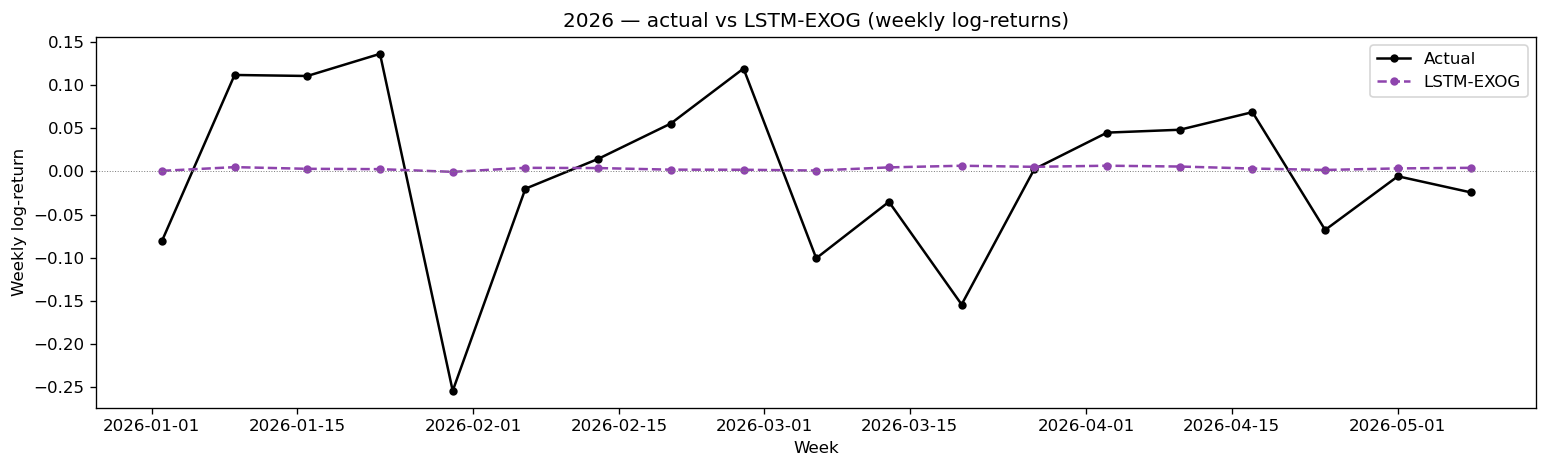

In [169]:
df26 = pd.DataFrame({"actual": actuals_arr, "pred": best_pred},
                    index=pd.DatetimeIndex(dates_arr))
df26 = df26.loc["2026":]

if df26.empty:
    print("No 2026 data in test set yet.")
else:
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(df26.index, df26["actual"], color="black",  lw=1.5, marker="o", ms=4, label="Actual")
    ax.plot(df26.index, df26["pred"],   color="#8e44ad", lw=1.5, marker="o", ms=4,
            ls="--", label=f"{best_name}")
    ax.axhline(0, color="grey", lw=0.6, ls=":")
    ax.set_title(f"2026 — actual vs {best_name} (weekly log-returns)", fontsize=12)
    ax.set_ylabel("Weekly log-return")
    ax.set_xlabel("Week")
    ax.legend()
    plt.tight_layout()
    plt.show()